<a href="https://colab.research.google.com/github/laurianedlz/Fundamentos-de-Optimizacion/blob/main/Practico_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradiente proyectado vs Nesterov proyectado

Sean $\mathcal{X} = \{x \in \mathbb{R}^n : -1 \le x_i \le 1, \, i = 1, \dots, n\}$, y $f: \mathbb{R}^n \to \mathbb{R}$ dada por:

$$f(x) = \frac{1}{2}\langle Ax, x \rangle - \langle b, x \rangle$$

con $A \in S_{++}^n$ y $b \in \mathbb{R}^n$.

a) Implementar una funcion que, dado $x \in \mathbb{R}^n$, devuelva $P_{\mathcal{X}}(x)$. Notar que

$$[P_{\mathcal{X}}(x)]_i = \max\{-1, \min\{1, x_i\}\}$$

In [19]:
import numpy as np

def projection(x):
  return np.clip(x,-1,1)

b) Implementar el método de gradiente proyectado con paso fijo $\alpha^k = 1$ y $s^k = t = 1/L$, donde $L$ es la constante de Lipschitz del gradiente $\nabla f(x) = Ax - b$. Verificar que $L = \lambda_{\text{max}}(A)$.

In [29]:
def gradf (x,A,b):
  return A@x-b

def f(x,A,b):
  return 0.5 * x.T @ A @ x - b.T @ x

def grad_proy_proximo_x (gradf,x,A,b,L):
  d=-gradf(x,A,b)
  p=1/L
  return projection(x-p*gradf(x,A,b))

def grad_proy (x0,n,gradf,A,b):
  x=[x0]
  tray=[f(x0,A,b)]
  L=np.max(np.linalg.eigvals(A))
  for i in range(n):
    x.append(grad_proy_proximo_x(gradf,x[i],A,b,L))
    tray.append(f(x[i+1],A,b))
  return np.array(tray)


Vamos a verificar que $L = \lambda_{\text{max}}(A)$ :

$$\nabla f(x) - \nabla f(y) = (Ax - b) - (Ay - b) = A(x - y)$$
$$\|\nabla f(x) - \nabla f(y)\| = \|A(x - y)\|$$


Dado que $A \in S_{++}^n$, el teorema espectral garantiza que existe una base ortonormal de vectores propios $\{u_1, \dots, u_n\}$ asociados a los valores propios $0 < \lambda_1 \le \dots \le \lambda_n = \lambda_{\text{máx}}$.

Sea $v = x - y$. Podemos expresar $v$ como una combinacion lineal en la base de vectores propios:
$$v = \sum_{i=1}^n \alpha_i u_i$$

La norma al cuadrado de $v$ es, por la ortonormalidad de los vectores propios:
$$\|v\|^2 = \sum_{i=1}^n \alpha_i^2$$

Aplicando la matriz $A$ al vector $v$:
$$Av = \sum_{i=1}^n \alpha_i A u_i = \sum_{i=1}^n \alpha_i \lambda_i u_i$$

Calculamos la norma al cuadrado de $Av$:
$$\|Av\|^2 = \sum_{i=1}^n (\alpha_i \lambda_i)^2 = \sum_{i=1}^n \lambda_i^2 \alpha_i^2$$

Dado que para todo $i$ se cumple que $\lambda_i \le \lambda_{\text{máx}}$, tenemos que $\lambda_i^2 \le \lambda_{\text{máx}}^2$. Por lo tanto:
$$\|Av\|^2 \le \sum_{i=1}^n \lambda_{\text{máx}}^2 \alpha_i^2 = \lambda_{\text{máx}}^2 \sum_{i=1}^n \alpha_i^2 = \lambda_{\text{máx}}^2 \|v\|^2$$

Entonces :
$$\|A(x - y)\| \le \lambda_{\text{máx}} \|x - y\|$$

Finalmente :
$$\|\nabla f(x) - \nabla f(y)\| \le  \lambda_{\max}(A) \|x - y\|$$

Entonces : $L=\lambda_{\max}(A)$


c) Implementar el método de gradiente proyectado acelerado de Nesterov:

$$x^{k+1} = P_{\mathcal{X}}(y^k - \alpha\nabla f(y^k))$$
$$t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$$
$$y^{k+1} = x^{k+1} + \frac{t_k - 1}{t_{k+1}}(x^{k+1} - x^k)$$

inicializando en $x^0 = P_{\mathcal{X}}(0), \, y^0 = x^0, \, t_0 = 1$.

In [43]:
## vamos a tomar alpha=1/L porque no anda con valores mayores a 1/L (gracias a gemini)
def metodo_nesterov(gradf,x0,y0,t0,n,A,b):
  old_x=x0
  old_y=y0
  old_t=t0
  tray=[f(x0,A,b)]
  L = np.max(np.linalg.eigvals(A))
  for i in range(n):
    x=projection(old_y-(1/L)*gradf(old_y,A,b))
    t=(1+np.sqrt(1+4*old_t**2))/2
    y=x+((old_t-1)/(t))*(x-old_x)
    old_x=x
    old_y=y
    old_t=t
    tray.append(f(x,A,b))
  return np.array(tray)

d) Tomar $n = 20$ y generar $A = Q^\top \text{diag}(d)Q$ donde $Q$ es el factor de la descomposición $QR$ de una matriz gaussiana aleatoria, y $d$ contiene valores propios distribuidos logarítmicamente entre $1$ y $\kappa = 100$. Tomar $b$ aleatorio con distribución normal estándar. Comparar la convergencia de ambos métodos graficando $f(x^k) - f^*$ en escala semilogarítmica.

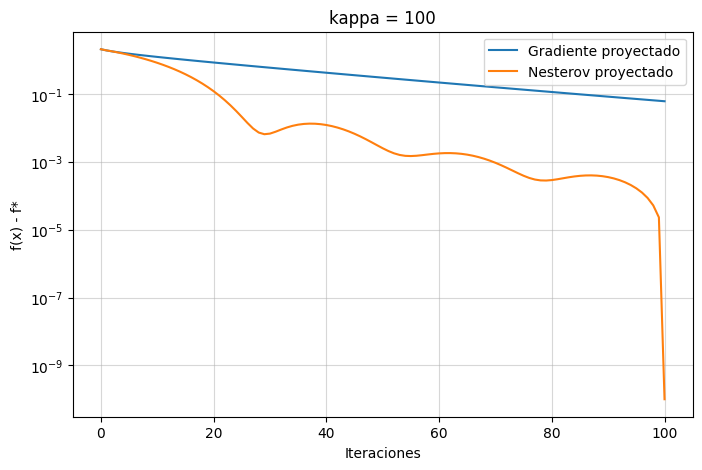

In [76]:
import matplotlib.pyplot as plt

x0=projection(np.zeros(20))
y0=x0
t0=1
Q, R = np.linalg.qr(np.random.randn(20, 20))
b = np.random.randn(20)

def generacion(kappa,n,f,Q,b):     ## n es es el numero de iteraciones
    d = np.exp(np.linspace(np.log(1), np.log(kappa), 20))
    A = Q.T @ np.diag(d) @ Q
    L = np.max(d)

    gp = grad_proy(x0,n,gradf,A,b)
    nest = metodo_nesterov(gradf,x0,y0,t0,n,A,b)
    min_gp=np.min(gp)
    min_nest=np.min(nest)
    f_star = min(min_gp,min_nest)

    plt.figure(figsize=(8, 5))

    plt.semilogy(np.array(gp) - f_star + 1e-10, label='Gradiente proyectado')
    plt.semilogy(np.array(nest) - f_star + 1e-10, label='Nesterov proyectado')
    plt.title(f'kappa = {kappa}')
    plt.xlabel('Iteraciones')
    plt.ylabel('f(x) - f*')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

generacion(100,100,f,Q,b)

Hay un pico que se observa en el grafico de Nesterov al alcanzar valores cercanos a $10^{-6}$ porque defini $f^*$ como el valor minimo global alcanzado por cualquier de los 2 algoritmos.
Entonces, cuando hacemos $f (x) - f^*$ en este punto es igual a 0.
La escala log no pudria representarlo, es poque ponemos el +1e-10, de esta manera, el grafico se puede mostrar aun hay un pico en este punto $x^*$.

e) Repetir el experimento de la parte d) para $\kappa = 10$ y $\kappa = 1000$. Comentar cómo afecta el número de condición a la convergencia de cada método.

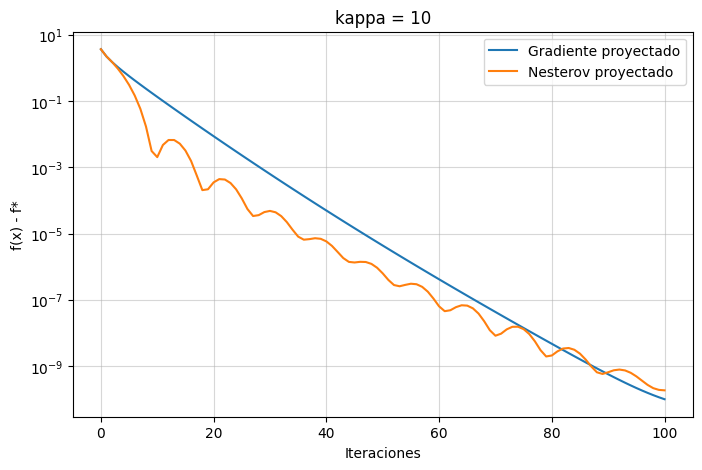

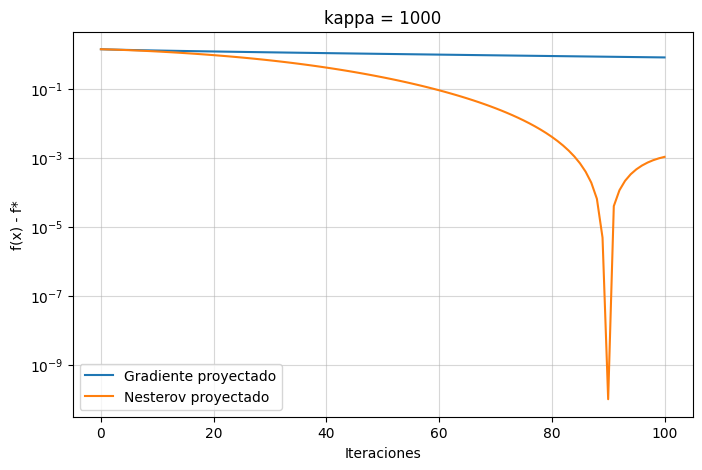

In [78]:
generacion(10,100,f,Q,b)
generacion(1000,100,f,Q,b)

Para ell gradiente proyectado, se observa que, al aumentar $\kappa$, la convergencia se vuelve muy lenta. Esto es porque el método no tiene memoria, obligandolo a oscilar en un "valle" estrecho sin poder avanzar muy bien hasta el minimo global.

El metodo de Nesterov utilisa un momentum, entonces logra una convergencia mas rapida que el gradiente simple, en partiular en problemas mal condicionados ($\kappa=1000$).
